In [37]:
!pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import wandb
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("WANDB_API_KEY")

if api_key:
    os.environ["WANDB_API_KEY"] = api_key
    wandb.login(key=api_key)
else:
    print("WANDB_API_KEY no está")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\50684\_netrc
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\50684\_netrc


In [39]:
import torch

# Configurar precisión para Tensor Cores (API nueva)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"TF32 para matmul: {torch.backends.cuda.matmul.allow_tf32}")
print(f"TF32 para cuDNN: {torch.backends.cudnn.allow_tf32}")

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
import subprocess
import sys

def run_training(cmd):
    result = subprocess.run(cmd, encoding='utf-8', errors='replace')
    return result.returncode

run_training([sys.executable, "train_model_a.py", "train.lr=1e-3", "dataset.batch_size=32", "train.epochs=50"])
run_training([sys.executable, "train_model_a.py", "train.lr=5e-4", "dataset.batch_size=64", "train.epochs=40"])
run_training([sys.executable, "train_model_a.py", "train.lr=1e-4", "dataset.batch_size=32", "train.epochs=60"])

run_training([sys.executable, "train_model_b.py", "model=distilled", "train.lr=1e-3", "dataset.batch_size=32", "train.epochs=50", "model.distillation.temperature=4.0", "model.distillation.alpha=0.7"])
run_training([sys.executable, "train_model_b.py", "model=distilled", "train.lr=5e-4", "dataset.batch_size=64", "train.epochs=40", "model.distillation.temperature=3.0", "model.distillation.alpha=0.5"])
run_training([sys.executable, "train_model_b.py", "model=distilled", "train.lr=1e-4", "dataset.batch_size=32", "train.epochs=60", "model.distillation.temperature=5.0", "model.distillation.alpha=0.8"])

run_training([sys.executable, "train_model_c.py", "model=unet_ae", "train.lr=1e-3", "dataset.batch_size=32", "train.epochs=50", "model.latent.dim=256", "model.reconstruction.loss=l1"])
run_training([sys.executable, "train_model_c.py", "model=unet_ae", "train.lr=5e-4", "dataset.batch_size=64", "train.epochs=40", "model.latent.dim=128", "model.reconstruction.loss=l2"])
run_training([sys.executable, "train_model_c.py", "model=unet_ae", "train.lr=1e-4", "dataset.batch_size=32", "train.epochs=60", "model.latent.dim=512", "model.reconstruction.loss=l1"])

0

# Evaluación de Anomalías con Embeddings

Sistema de detección de anomalías basado en representaciones vectoriales (embeddings).
- Carga de embeddings desde conjuntos de validación y prueba
- Cálculo de score de anomalía mediante distancia de Mahalanobis
- Determinación de umbral mediante percentil sobre datos normales
- Evaluación cuantitativa: Accuracy, Precision, Recall, F1-Score, AUC-ROC

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.covariance import EmpiricalCovariance
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga de Embeddings

Extracción de representaciones vectoriales de los modelos entrenados.

In [ ]:
def load_embeddings_from_npz(npz_file):
    """
    Carga embeddings desde archivo .npz
    
    Args:
        npz_file: Ruta al archivo .npz
    
    Returns:
        dict con embeddings_val, labels_val, embeddings_test, labels_test
    """
    print(f"Cargando embeddings desde: {npz_file}")
    
    data_npz = np.load(npz_file, allow_pickle=True)
    
    print(f"Keys disponibles: {list(data_npz.keys())}")
    
    # Extracción de arrays
    all_embeddings = data_npz['embeddings']
    all_labels = data_npz['labels']
    
    print(f"Total embeddings: {all_embeddings.shape}")
    print(f"Total labels: {all_labels.shape}")
    print(f"  - Good (0): {np.sum(all_labels == 0)}")
    print(f"  - Defect (1): {np.sum(all_labels == 1)}")
    
    # Separación de conjuntos según labels
    # Validación: muestras normales (label 0)
    # Test: totalidad de muestras (normales + defectos)
    normal_mask = all_labels == 0
    
    embeddings_val = all_embeddings[normal_mask]
    labels_val = all_labels[normal_mask]
    
    embeddings_test = all_embeddings
    labels_test = all_labels
    
    print(f"\n✓ Embeddings validación (normales): {embeddings_val.shape}")
    print(f"✓ Labels validación: {labels_val.shape}")
    print(f"✓ Embeddings prueba (todos): {embeddings_test.shape}")
    print(f"✓ Labels prueba: {labels_test.shape}")
    
    return {
        'embeddings_val': embeddings_val,
        'labels_val': labels_val,
        'embeddings_test': embeddings_test,
        'labels_test': labels_test
    }

# SELECCIONAR MODELO - Cambiar según cuál quieras evaluar
# Opciones: "LitClassifier", "ModelB_Distilled", "ModelC_UNet"
MODEL_NAME = "LitClassifier"  # Cambiar por el modelo que quieras evaluar

# Cargar embeddings
embedding_file = f"./embeddings/{MODEL_NAME}_embeddings.npz"
data = load_embeddings_from_npz(embedding_file)

Cargando embeddings desde: ./embeddings/LitClassifier_embeddings.npz
Keys disponibles: ['embeddings', 'labels', 'defects']
Total embeddings: (1180, 128)
Total labels: (1180,)
  - Good (0): 326
  - Defect (1): 854

✓ Embeddings validación (normales): (326, 128)
✓ Labels validación: (326,)
✓ Embeddings prueba (todos): (1180, 128)
✓ Labels prueba: (1180,)


## 2. Preparar Datos para Detección de Anomalías

Separar embeddings normales y anómalos, y verificar la distribución de las clases.

In [ ]:
# Codificación de labels: 0 = normal, 1 = defecto

print("=== Distribución en Validación ===")
print(f"Normales: {np.sum(data['labels_val'] == 0)}")
print(f"Anómalos: {np.sum(data['labels_val'] == 1)}")

print("\n=== Distribución en Prueba ===")
print(f"Normales: {np.sum(data['labels_test'] == 0)}")
print(f"Anómalos: {np.sum(data['labels_test'] == 1)}")

embeddings_val_normal = data['embeddings_val'][data['labels_val'] == 0]
print(f"\nEmbeddings normales en validación: {embeddings_val_normal.shape}")

=== Distribución en Validación ===
Normales: 326
Anómalos: 0

=== Distribución en Prueba ===
Normales: 326
Anómalos: 854

Embeddings normales en validación: (326, 128)


## 3. Calcular Distribución Normal (Media y Covarianza)

Usar datos de validación (solo normales) para estimar la distribución normal multivariante.

In [ ]:
def fit_gaussian_distribution(embeddings):
    """
    Calcula media y covarianza de los embeddings normales.
    
    Args:
        embeddings: Array numpy (n_samples, embedding_dim)
    
    Returns:
        mean: Vector de media
        cov: Matriz de covarianza
        cov_inv: Inversa de la matriz de covarianza
    """
    mean = np.mean(embeddings, axis=0)
    
    cov_estimator = EmpiricalCovariance()
    cov_estimator.fit(embeddings)
    
    cov = cov_estimator.covariance_
    cov_inv = cov_estimator.precision_
    
    print(f"Media calculada: shape {mean.shape}")
    print(f"Covarianza: shape {cov.shape}")
    
    return mean, cov, cov_inv

# Calcular distribución de normales en validación
mean_normal, cov_normal, cov_inv_normal = fit_gaussian_distribution(embeddings_val_normal)

Media calculada: shape (128,)
Covarianza: shape (128, 128)


## 4. Calcular Score de Anomalía (Distancia de Mahalanobis)

La distancia de Mahalanobis mide qué tan lejos está un punto de la distribución normal, considerando la correlación entre dimensiones.

In [ ]:
def mahalanobis_distance(embeddings, mean, cov_inv):
    """
    Calcula la distancia de Mahalanobis para cada embedding.
    
    Args:
        embeddings: Array (n_samples, embedding_dim)
        mean: Vector de media
        cov_inv: Inversa de matriz de covarianza
    
    Returns:
        distances: Array de distancias (n_samples,)
    """
    diff = embeddings - mean
    # Distancia de Mahalanobis: sqrt((x-μ)ᵀ Σ⁻¹ (x-μ))
    distances = np.sqrt(np.sum(np.dot(diff, cov_inv) * diff, axis=1))
    return distances

def euclidean_distance(embeddings, mean):
    """
    Calcula la distancia euclidiana para cada embedding.
    
    Args:
        embeddings: Array (n_samples, embedding_dim)
        mean: Vector de media
    
    Returns:
        distances: Array de distancias (n_samples,)
    """
    return np.linalg.norm(embeddings - mean, axis=1)

print("Calculando scores de anomalía...")

scores_val = mahalanobis_distance(embeddings_val_normal, mean_normal, cov_inv_normal)
scores_test = mahalanobis_distance(data['embeddings_test'], mean_normal, cov_inv_normal)

print(f"Scores validación: min={scores_val.min():.3f}, max={scores_val.max():.3f}, mean={scores_val.mean():.3f}")
print(f"Scores prueba: min={scores_test.min():.3f}, max={scores_test.max():.3f}, mean={scores_test.mean():.3f}")

Calculando scores de anomalía...
Scores validación: min=4.946, max=17.653, mean=10.819
Scores prueba: min=4.750, max=103.049, mean=18.432


## 5. Definir Umbral con Percentil

Usar un percentil alto (ej. 95%) de los scores normales de validación como umbral.

In [ ]:
PERCENTILE = 95

threshold = np.percentile(scores_val, PERCENTILE)
print(f"Umbral definido (percentil {PERCENTILE}): {threshold:.3f}")

predictions_test = (scores_test > threshold).astype(int)

print(f"\nPredicciones en prueba:")
print(f"Predichos como normales (0): {np.sum(predictions_test == 0)}")
print(f"Predichos como anómalos (1): {np.sum(predictions_test == 1)}")

Umbral definido (percentil 95): 15.773

Predicciones en prueba:
Predichos como normales (0): 734
Predichos como anómalos (1): 446


## 6. Evaluar con Métricas de Clasificación

Calcular métricas estándar: Accuracy, Precision, Recall, F1-Score y AUC-ROC.

In [ ]:
y_true = data['labels_test']
y_pred = predictions_test
y_scores = scores_test

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
auc_roc = roc_auc_score(y_true, y_scores)

print("MÉTRICAS DE DETECCIÓN DE ANOMALÍAS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (de los predichos anómalos, cuántos lo son)")
print(f"Recall:    {recall:.4f}  (de los realmente anómalos, cuántos detectamos)")
print(f"F1-Score:  {f1:.4f}  (balance entre precision y recall)")
print(f"AUC-ROC:   {auc_roc:.4f}  (capacidad de separar normales de anómalos)")
print("=" * 60)

# Crear tabla de resultados
results_df = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Valor': [accuracy, precision, recall, f1, auc_roc]
})

print("\n", results_df.to_string(index=False))

MÉTRICAS DE DETECCIÓN DE ANOMALÍAS
Accuracy:  0.6254
Precision: 0.9619  (de los predichos anómalos, cuántos lo son)
Recall:    0.5023  (de los realmente anómalos, cuántos detectamos)
F1-Score:  0.6600  (balance entre precision y recall)
AUC-ROC:   0.6858  (capacidad de separar normales de anómalos)

   Métrica    Valor
 Accuracy 0.625424
Precision 0.961883
   Recall 0.502342
 F1-Score 0.660000
  AUC-ROC 0.685759


## 7. Visualizaciones

Gráficas para visualizar la separación entre normales y anómalos.

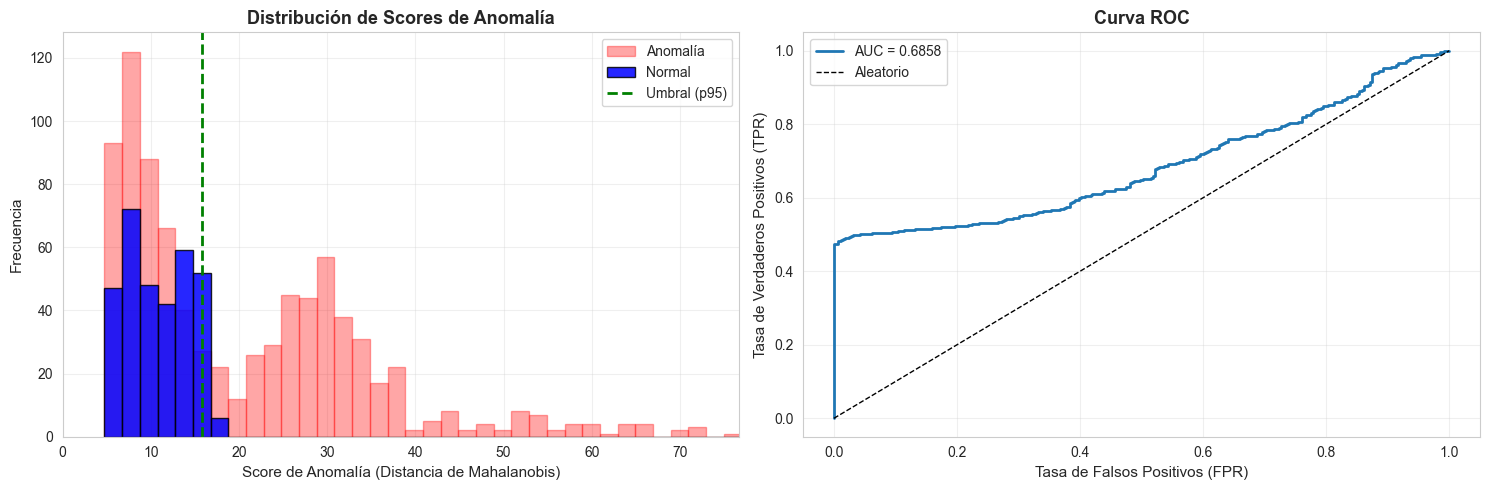

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

scores_test_normal = scores_test[y_true == 0]
scores_test_anomaly = scores_test[y_true == 1]

# Definir bins comunes
bins = np.linspace(scores_test.min(), scores_test.max(), 50)

# Histograma
axes[0].hist(scores_test_anomaly, bins=bins, alpha=0.35,
             label='Anomalía', color='red', edgecolor='red')
axes[0].hist(scores_test_normal, bins=bins, alpha=0.85,
             label='Normal', color='blue', edgecolor='black')
axes[0].axvline(threshold, color='green', linestyle='--', linewidth=2,
                label=f'Umbral (p{PERCENTILE})')

# Opcional: recortar extremos para ver mejor la izquierda
axes[0].set_xlim(0, np.percentile(scores_test, 99))

axes[0].set_xlabel('Score de Anomalía (Distancia de Mahalanobis)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de Scores de Anomalía', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva ROC
fpr, tpr, thresholds_roc = roc_curve(y_true, y_scores)
axes[1].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_roc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[1].set_title('Curva ROC', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


El histograma muestra la distribución de los scores de anomalía en el conjunto de prueba. Las muestras normales se concentran en valores bajos de distancia de Mahalanobis, mientras que las anomalías presentan una dispersión mayor y una cola hacia scores altos. El umbral se fija en el percentil 95 de los scores de las muestras normales, de forma que la mayoría de estas quedan a la izquierda de la línea verde, mientras que las anomalías más pronunciadas se sitúan claramente por encima de dicho valor.



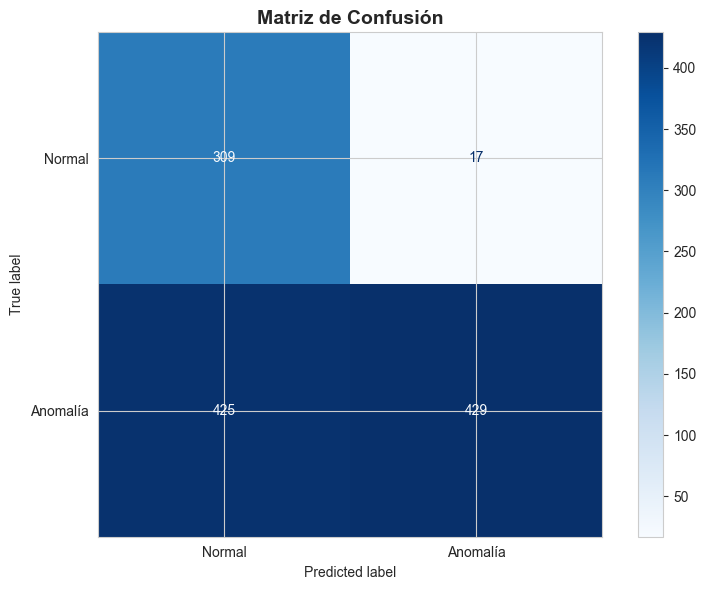


Matriz de Confusión:
  Verdaderos Negativos (TN): 309
  Falsos Positivos (FP): 17
  Falsos Negativos (FN): 425
  Verdaderos Positivos (TP): 429

Tasa de Falsos Positivos: 0.0521
Tasa de Falsos Negativos: 0.4977


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomalía'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Matriz de Confusión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calcular tasas
tn, fp, fn, tp = cm.ravel()
print(f"\nMatriz de Confusión:")
print(f"  Verdaderos Negativos (TN): {tn}")
print(f"  Falsos Positivos (FP): {fp}")
print(f"  Falsos Negativos (FN): {fn}")
print(f"  Verdaderos Positivos (TP): {tp}")
print(f"\nTasa de Falsos Positivos: {fp/(fp+tn):.4f}")
print(f"Tasa de Falsos Negativos: {fn/(fn+tp):.4f}")

## 8. Análisis de Sensibilidad del Umbral

Explorar cómo diferentes percentiles afectan las métricas.

 Percentil    Umbral  Accuracy  Precision   Recall  F1-Score
        90 15.348763  0.616102   0.929336 0.508197  0.657078
        92 15.546979  0.618644   0.942982 0.503513  0.656489
        94 15.699201  0.623729   0.955556 0.503513  0.659509
        95 15.772751  0.625424   0.961883 0.502342  0.660000
        96 16.031828  0.627119   0.970455 0.500000  0.659969
        98 16.777533  0.624576   0.983529 0.489461  0.653636
        99 17.066459  0.622034   0.990385 0.482436  0.648819


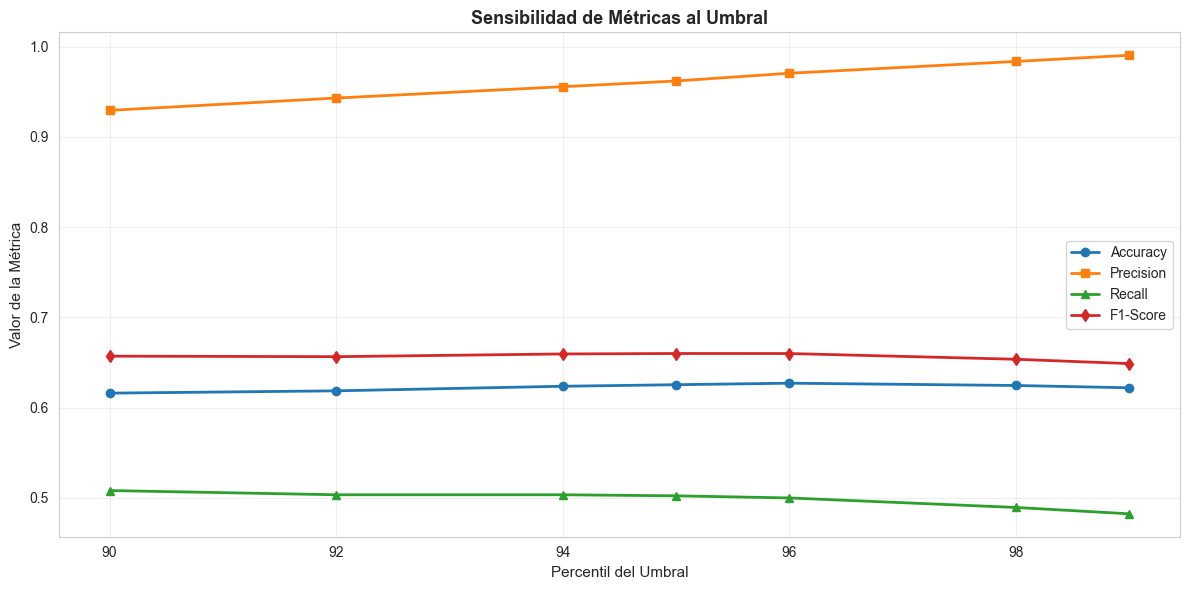

In [ ]:
percentiles = [90, 92, 94, 95, 96, 98, 99]
results = []

for p in percentiles:
    thresh = np.percentile(scores_val, p)
    preds = (scores_test > thresh).astype(int)
    
    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds, zero_division=0)
    f1_p = f1_score(y_true, preds, zero_division=0)
    
    results.append({
        'Percentil': p,
        'Umbral': thresh,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1_p
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Gráfica de métricas vs percentil
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(results_df['Percentil'], results_df['Accuracy'], marker='o', label='Accuracy', linewidth=2)
ax.plot(results_df['Percentil'], results_df['Precision'], marker='s', label='Precision', linewidth=2)
ax.plot(results_df['Percentil'], results_df['Recall'], marker='^', label='Recall', linewidth=2)
ax.plot(results_df['Percentil'], results_df['F1-Score'], marker='d', label='F1-Score', linewidth=2)
ax.set_xlabel('Percentil del Umbral', fontsize=11)
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Sensibilidad de Métricas al Umbral', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Resumen y Conclusiones

In [ ]:
print("Resumen")
print(f"\nConfiguración:")
print(f"  - Método: Distancia de Mahalanobis")
print(f"  - Umbral: Percentil {PERCENTILE} de validación = {threshold:.3f}")
print(f"  - Muestras validación (normales): {len(embeddings_val_normal)}")
print(f"  - Muestras prueba: {len(y_true)} (Normales: {np.sum(y_true==0)}, Anómalos: {np.sum(y_true==1)})")

print(f"\nResultados:")
print(f" Accuracy:  {accuracy:.4f}")
print(f" Precision: {precision:.4f}")
print(f" Recall:    {recall:.4f}")
print(f" F1-Score:  {f1:.4f}")
print(f" AUC-ROC:   {auc_roc:.4f}")

print(f"\nObservaciones:")
if auc_roc > 0.9:
    print("  • excelente separación entre normales y anómalos (AUC > 0.9)")
elif auc_roc > 0.8:
    print("  • buena separación entre normales y anómalos (AUC > 0.8)")
else:
    print("  • Separación moderada - considerar ajustar el modelo o features")

if recall > 0.8:
    print("  • Alto recall - detecta la mayoría de anomalías")
else:
    print("  • Recall mejorable - ajustar umbral para detectar más anomalías")

if precision > 0.8:
    print("  • Alta precisión, pocas falsas alarmas")
else:
    print("  • Precisión mejorable - hay falsos positivos")

print("=" * 70)

Resumen

Configuración:
  - Método: Distancia de Mahalanobis
  - Umbral: Percentil 95 de validación = 15.773
  - Muestras validación (normales): 326
  - Muestras prueba: 1180 (Normales: 326, Anómalos: 854)

Resultados:
  Accuracy:  0.6254
  Precision: 0.9619
 Recall:    0.5023
  F1-Score:  0.6600
  AUC-ROC:   0.6858

Observaciones:
  • Separación moderada - considerar ajustar el modelo o features
  • Recall mejorable - ajustar umbral para detectar más anomalías
  • Alta precisión, pocas falsas alarmas
